## Student name : Mujtaba Hejji Alnuwaysir
## ID : 2240007941
## Class : 7MA2

## Task#1: Thresholding
## Step#1: Apply thresholding with a fixed threshold on an image:


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

In [2]:
import cv2

img = cv2.imread("Parrot.png", cv2.IMREAD_GRAYSCALE)
print(img)

[[171 171 171 ... 182 182 182]
 [171 171 171 ... 182 182 182]
 [171 171 171 ... 182 183 183]
 ...
 [ 34  36  37 ... 126 127 127]
 [ 34  35  37 ... 126 127 127]
 [ 34  35  37 ... 127 127 127]]


In [3]:
ret, thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

In [4]:
cv2.imshow('Thresholded', thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)

cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Task#2: Histogram Processing

## Step#1: Load necessary libraries


In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure


## Step#2: Load moon image

In [8]:
img = data.moon()

## Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

In [9]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

## Step#4: Display the image with its histogram of (step#2)  and (step#3)

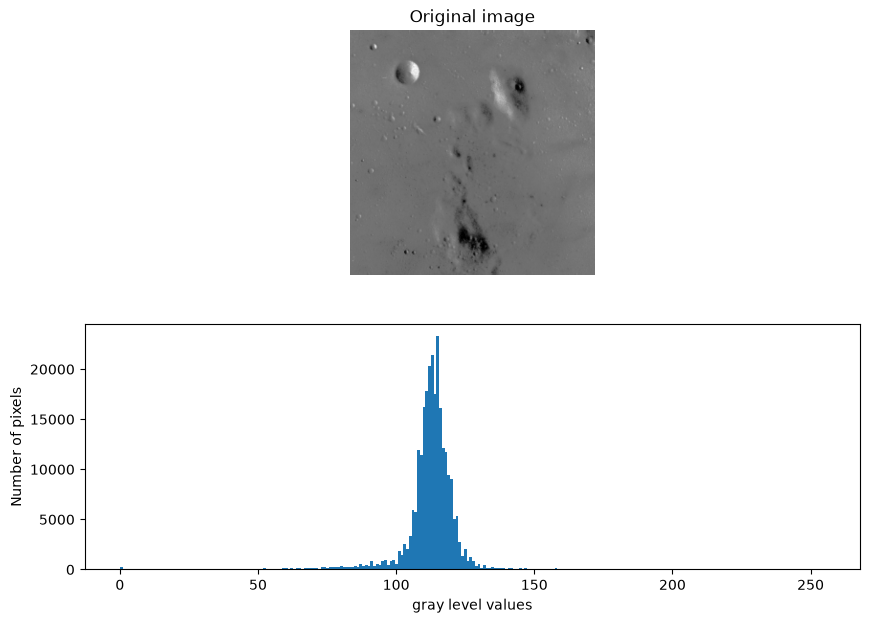

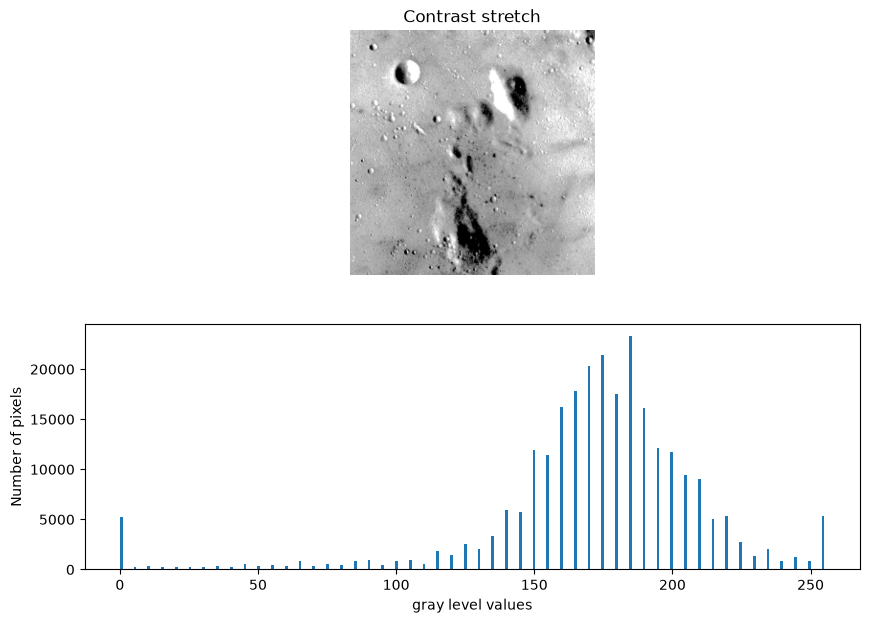

In [10]:
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 



fig = plt.figure(figsize=(10, 7)) 	
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show()


## Assessment

## Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3rd and 80th percentiles, and plot the histogram

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

img = data.moon()

def show(image, title, rng=(0, 255)):
    fig = plt.figure(figsize=(10, 7))
    fig.add_subplot(2, 1, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(title)
    fig.add_subplot(2, 1, 2)
    plt.hist(image.flat, bins=256, range=rng)
    plt.xlabel('gray level values')
    plt.ylabel('Number of pixels')
    plt.show()

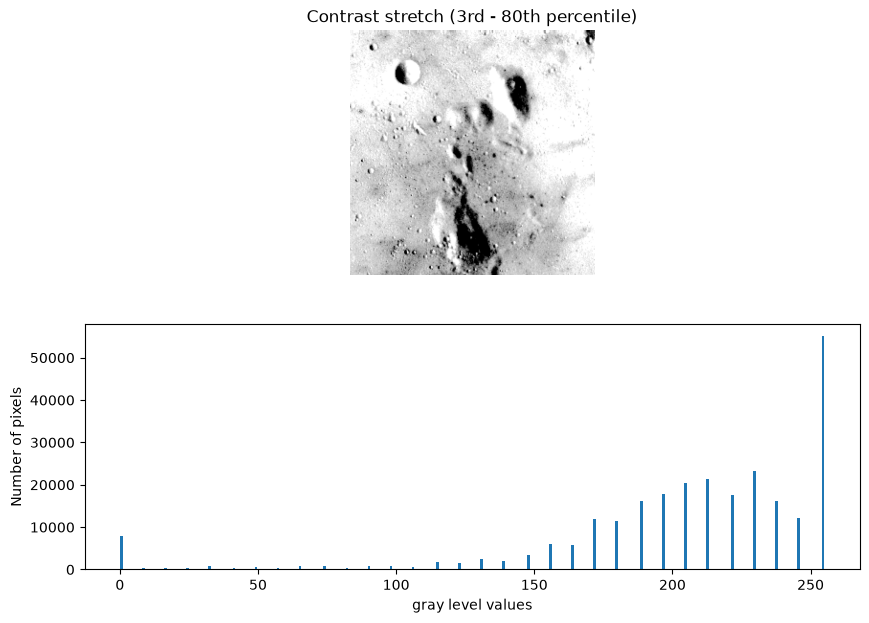

In [13]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))
show(img_rescale, 'Contrast stretch (3rd - 80th percentile)')

## Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

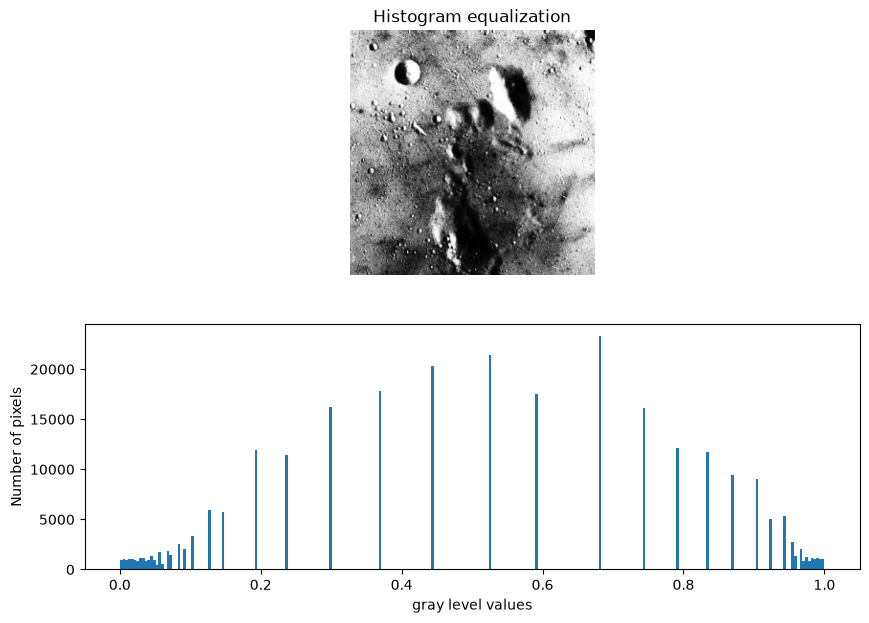

In [14]:
img_eq = exposure.equalize_hist(img)
show(img_eq, 'Histogram equalization', rng=(0, 1))

## Task#3: Use the rocket (as reference) and Chelsea images (from skimage.data) and implement histogram matching

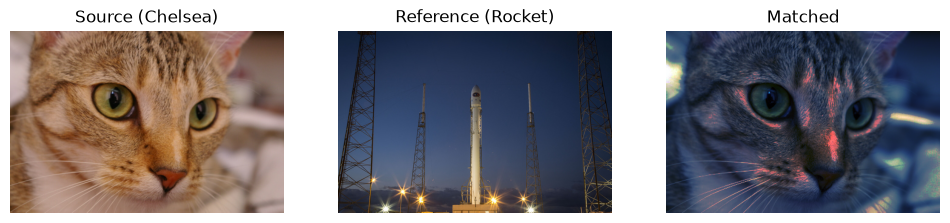

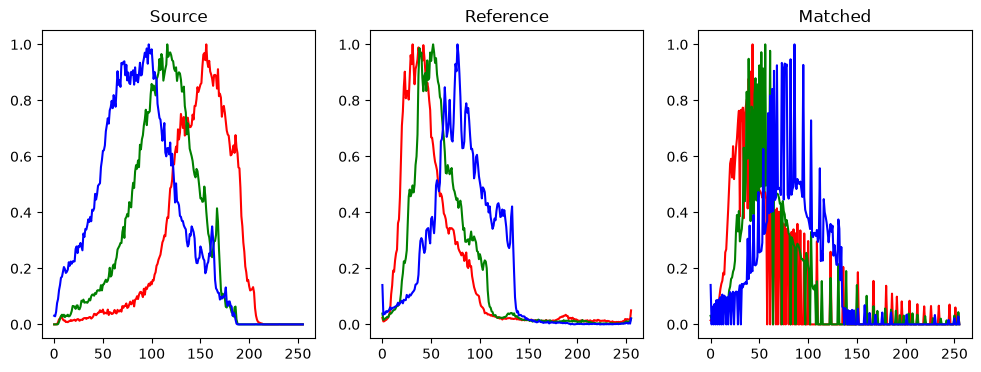

In [15]:
reference = data.rocket()   
image = data.chelsea()      

matched = exposure.match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [image, reference, matched],
                     ['Source (Chelsea)', 'Reference (Rocket)', 'Matched']):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis('off')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [image, reference, matched],
                     ['Source', 'Reference', 'Matched']):
    for i, c in enumerate(['red', 'green', 'blue']):
        h, bins = exposure.histogram(im[..., i], source_range='dtype')
        ax.plot(bins, h / h.max(), color=c)
    ax.set_title(t)
plt.show()